# Bot vs. Crowd — settled-market post-mortem

Scores the bot's probabilities against the **crowd mean** on already-settled
Probability Cup markets, using realized outcomes (Brier score, lower = better).

**Crowd data source.** The bot REST API (`/api/v1`) deliberately hides crowd
consensus. The SportPredict *web* API (`/api`) exposes it for settled markets via
`POST /probability/match-crowd-stats` → `prediction_average` (crowd mean, 0–100)
and `current_value` (outcome, 0/100). See `bot/web.py`.

Pre-match odds are purged a few days after kickoff, so the bot can only re-price
recently-settled matches; older ones contribute crowd/outcome but no bot price.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt

from bot.sportspredict import SportPredict
from bot.web import WebAPI
from bot.apifootball import APIFootball
from bot.pipeline import run_match
from bot.oddsapi import OddsAPI

N_MATCHES = 12  # most-recent settled matches to evaluate (odds still live)

sp, web, af, oa = SportPredict(), WebAPI(), APIFootball(), OddsAPI()
event = sp.event()
lobby = sp.lobby(event["id"])
print("event:", event["title"], "| lobby:", lobby["id"])

event: Jump Trading Probability Cup | lobby: 8df8038c-fd2c-4a5f-be4e-0e11d5966c05


In [2]:
# Pull settled matches (recent first), run the bot, join to crowd + outcome.
settled = web.settled_matches(event["id"], limit=N_MATCHES)
rows = []
for sm in settled:
    crowd = web.crowd_stats(sm["id"], lobby["id"])
    res = run_match(sm, crowd, af, oa)   # AF -> Odds API -> derive (web layer off here)
    bot = {p.market_id: p.probability for p in res.predictions}
    for c in crowd:
        if c["id"] in bot and c["current_value"] in (0, 100):
            rows.append({
                "match": sm["name"],
                "question": c["question"],
                "bot": bot[c["id"]],
                "crowd": c["prediction_average"] / 100.0,
                "outcome": c["current_value"] // 100,
            })
    print(f"{sm['name']:<22} bot-priced {len(bot)}/{len(crowd)}")

df = pd.DataFrame(rows)
df["brier_bot"] = (df["bot"] - df["outcome"]) ** 2
df["brier_crowd"] = (df["crowd"] - df["outcome"]) ** 2
print(f"\nHead-to-head questions (bot priced AND settled): {len(df)}")
df.head()

New Zealand vs EGY     bot-priced 6/10


URU vs CPV             bot-priced 3/10


BEL vs IRN             bot-priced 6/10


ESP vs KSA             bot-priced 4/10


TUN vs JPN             bot-priced 6/9


...

TUR vs PAR             bot-priced 4/10


BRA vs Haiti           bot-priced 6/10


SCO vs MAR             bot-priced 6/10


USA vs AUS             bot-priced 6/9

Head-to-head questions (bot priced AND settled): 61


,match,question,bot,crowd,outcome,brier_bot,brier_crowd
0,New Zealand vs EGY,Will New Zealand commit more fouls than Egypt?,0.510905,0.505312,1,0.239214,0.244716
1,New Zealand vs EGY,Will Egypt be caught offside 2 or more times?,0.415307,0.492997,0,0.172480,0.243046
2,New Zealand vs EGY,Will the second half have more goals than the ...,0.426862,0.491684,1,0.328487,0.258385
3,New Zealand vs EGY,Will there be 4 or more total cards shown?,0.350178,0.433644,0,0.122624,0.188047
4,New Zealand vs EGY,Will New Zealand win the match?,0.164049,0.227857,0,0.026912,0.051919


In [3]:
# Aggregate scorecard.
n = len(df)
summary = pd.DataFrame({
    "mean_brier": [df.brier_bot.mean(), df.brier_crowd.mean(), ((0.5) ** 2)],
    "directional_acc": [
        ((df.bot > 0.5) == (df.outcome == 1)).mean(),
        ((df.crowd > 0.5) == (df.outcome == 1)).mean(),
        float("nan"),
    ],
}, index=["bot", "crowd", "coin-flip (0.5)"])
wins = (df.brier_bot < df.brier_crowd).sum()
print(f"Bot beats crowd on {wins}/{n} questions ({wins/n:.0%})")
print(f"Mean Brier  — bot {df.brier_bot.mean():.4f}  vs  crowd {df.brier_crowd.mean():.4f}")
summary

Bot beats crowd on 32/61 questions (52%)
Mean Brier  — bot 0.2272  vs  crowd 0.2278


,mean_brier,directional_acc
bot,0.227173,0.590164
crowd,0.227849,0.672131
coin-flip (0.5),0.250000,NaN


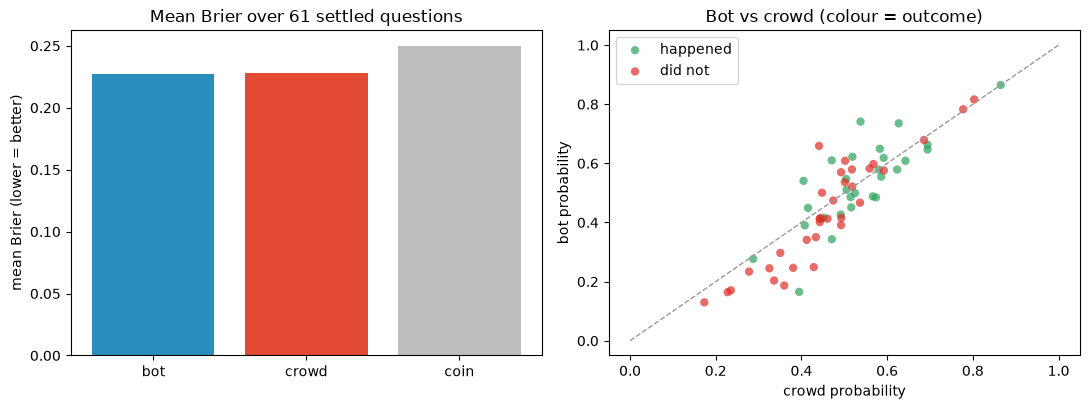

In [4]:
# Left: mean Brier (lower is better). Right: bot vs crowd probabilities,
# coloured by outcome (top-right & bottom-left quadrants = both correct).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.bar(["bot", "crowd", "coin"],
        [df.brier_bot.mean(), df.brier_crowd.mean(), 0.25],
        color=["#2b8cbe", "#e34a33", "#bdbdbd"])
ax1.set_ylabel("mean Brier (lower = better)")
ax1.set_title(f"Mean Brier over {n} settled questions")

for o, c, lbl in [(1, "#2ca25f", "happened"), (0, "#de2d26", "did not")]:
    sub = df[df.outcome == o]
    ax2.scatter(sub.crowd, sub.bot, c=c, alpha=0.7, label=lbl, edgecolors="none")
ax2.plot([0, 1], [0, 1], "--", color="#999", lw=1)
ax2.set_xlabel("crowd probability"); ax2.set_ylabel("bot probability")
ax2.set_title("Bot vs crowd (colour = outcome)"); ax2.legend()
plt.tight_layout(); plt.show()

In [5]:
# Where do bot and crowd disagree most? (largest |bot - crowd|)
df["disagree"] = (df.bot - df.crowd).abs()
cols = ["match", "question", "bot", "crowd", "outcome", "brier_bot", "brier_crowd"]
df.sort_values("disagree", ascending=False)[cols].head(10).round(2)

,match,question,bot,crowd,outcome,brier_bot,brier_crowd
19,TUN vs JPN,Will Japan commit more fouls than Tunisia?,0.17,0.39,1,0.70,0.37
28,ECU vs Curacao,Will Ecuador commit more fouls than Curaçao?,0.66,0.44,0,0.43,0.19
17,ESP vs KSA,Will Spain be caught offside 2 or more times?,0.74,0.54,1,0.07,0.21
58,USA vs AUS,Will both teams score AND the match have 3 or ...,0.25,0.43,0,0.06,0.18
54,SCO vs MAR,Will both teams score AND the match have 3 or ...,0.19,0.36,0,0.03,0.13
6,URU vs CPV,Will Uruguay commit more fouls than Cape Verde?,0.61,0.47,1,0.15,0.28
43,BRA vs Haiti,Will Haiti be caught offside 2 or more times?,0.54,0.40,1,0.21,0.35
9,BEL vs IRN,Will both teams score AND the match have 3 or ...,0.25,0.38,0,0.06,0.14
55,USA vs AUS,Will Australia finish with more corner kicks t...,0.20,0.34,0,0.04,0.11
38,NED vs SWE,Will both teams score AND the match have 3 or ...,0.34,0.47,1,0.43,0.28


**Reading it.** Lower mean Brier wins. The bot prices these via the odds
cascade (API-Football → Odds API → derived compounds). The web-search layer
is **disabled here** — a web search on a past match could leak the result;
it only runs live on upcoming matches.

Caveat: small sample — only recently-settled matches still have live odds.